In [1]:
import numpy as np
import h5py
import time

import sys
from pathlib import Path

SRC = Path.cwd().parent
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from matplotlib import pyplot as plt
from helpers.simulation import *
from helpers.qtransform import *
from dataset_generation.gw_class_gen import *
from dataset_generation.noise_psd_gen import *
from helpers.config import *
from model_training.model import *

from scipy.stats import truncnorm
from scipy.stats import gaussian_kde
from scipy.signal import find_peaks

import torch
from torch.utils.data import Dataset, random_split, DataLoader, Subset
import torchvision.models as models
import torch.nn as nn
from sklearn.metrics import confusion_matrix
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

/opt/anaconda3/envs/gwaves_lisa_py311/lib/python3.11/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal
PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


In [2]:
plt.rcParams.update({
    "font.size": 15,
    "axes.labelsize": 15,
    "axes.titlesize": 15,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "text.usetex": False,
    "font.family": "serif"
})

## Figure -1

In [79]:
with h5py.File(orbits_path, 'r') as orb:
    orb_t0 = orb.attrs['t0']
    orb_size = orb.attrs['size']
    orb_dt = orb.attrs['dt']

pipe = {'t0': orb_t0 + orb_size*orb_dt/2, 'dt': 1,'size': int(10 * 3600 / 1),
        't_inj': 5 * 3600, 'keep_noises': ['test-mass', 'oms']}

gws = [{'type': 'BinaryInspiralGW', 'm1': 1e5, 'm2': 1e5, 'd': 1e4,
        'spin1': 0, 'spin2': 0, 't_inj': pipe['t_inj']-1*3600, 'iota': 0,
        'gw_beta':0, 'gw_lambda':0}]
glitches = [{'type':'IntegratedShapeletGlitch', 't_inj': pipe['t_inj'] + 1 * 3600, 'beta':4.32e1,
             'level':2*4.91e-13*4.32e1, 'inj_point':'tm_13'}]
    
run_simulation(gws, glitches, pipe,
                gw_path, glitch_path, orbits_path,
                simulation_path,
                disable_noise=pipe['keep_noises'])
raw_dict = run_tdi(simulation_path, pipe)


You are using an orbit file in a version that might not be fully supported
Cannot read sampling parameters from '/Users/aryamannrao/Documents/MSc/LISAGlitchSignalClassifier/dist/default_gw_output.h5'
You are using an orbit file in a version that might not be fully supported
Using default set of locking beatnote frequencies might cause interferometric beatnote frequencies to fall outside the requirement range of 5..25 MHz
You are using a measurement file in a version that might not be fully supported (got '2.1.0', official support up to '2.0')


In [80]:
event = 5*3600
channel = 'A'
res = 256
tdi_dict = make_tdi_dict(raw_dict['X'], raw_dict['Y'], raw_dict['Z'], whiten=False)

start = time.time()
QT = np.zeros((2, res, res))
t_axes = np.zeros((2, res))
f_axes = np.zeros((2, res))

threshold = 8
Qvals = [6, 16]
T_opt = []
for i in range(QT.shape[0]):
    t_axis, f_axis, data = generate_qscan(tdi_dict, channel, pipe, event, resolution=res,
                             frange=(1e-4, 1e-1), trange=(-3, 3), Q=Qvals[i])
    t_axes[i] = t_axis
    f_axes[i] = f_axis
    QT[i] = data

    snr = np.sqrt(data**2 - 1)
    _, T_grid = np.meshgrid(np.log10(f_axis), t_axis/3600, indexing="ij")
    T_opt.append(T_grid[snr >= threshold])

T_opt = np.concatenate(T_opt)
end = time.time()
print(end - start)

0.41666293144226074


In [81]:
from scipy.stats import gaussian_kde
from scipy.signal import find_peaks

snr = np.sqrt(QT**2-1)
times = np.linspace(np.min(t_axes)/3600, np.max(t_axes)/3600, 250)
pdf = gaussian_kde(T_opt)(times)
peaks, _ = find_peaks(pdf, width=1, prominence=0.05)
ymax = gaussian_kde(T_opt)(times[peaks])

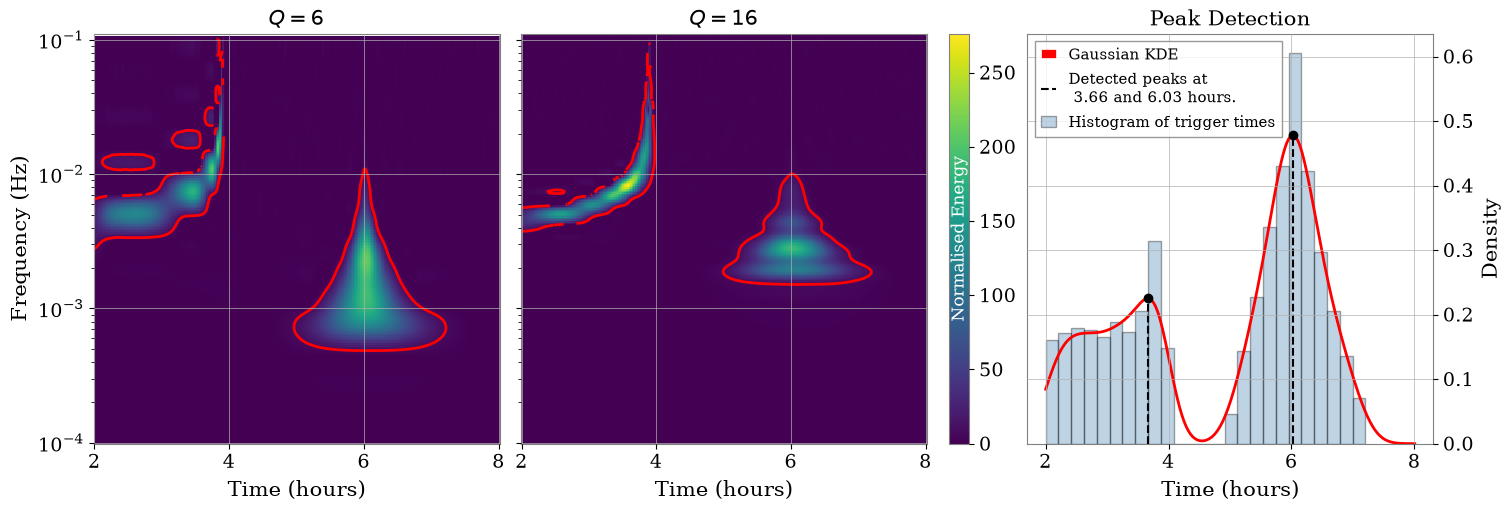

In [82]:
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import numpy as np

THRESHOLD = 8

# Common colour scale
vmin = np.min(QT)
vmax = np.max(QT)
norm = Normalize(vmin=vmin, vmax=vmax)

fig, ax = plt.subplots(
    1, 3,
    figsize=(15, 5),
    gridspec_kw={"width_ratios": [1, 1, 1]},
    constrained_layout=True,
)

# Share y-axis only for the two QT plots
ax[1].sharey(ax[0])

####################################################
# Q-transform panels
####################################################
for i in range(2):

    im = ax[i].pcolormesh(
        t_axes[i] / 3600,          # seconds -> hours
        f_axes[i],
        QT[i],
        shading="auto",
        cmap="viridis",
        norm=norm
    )

    snr = np.sqrt(QT[i]**2 - 1)

    ax[i].contour(
        t_axes[i] / 3600,
        f_axes[i],
        snr,
        levels=[THRESHOLD],
        colors="red",
        linewidths=2
    )

    ax[i].set_yscale("log")
    ax[i].set_xlabel("Time (hours)")
    ax[i].set_title(f"$Q={Qvals[i]}$")

ax[0].set_ylabel("Frequency (Hz)")
ax[1].set_ylabel("")
ax[1].tick_params(labelleft=False)
####################################################
# Shared colourbar for QT plots
####################################################
cbar = fig.colorbar(
    im,
    ax=ax[:2],
    location="right",
    pad=0.02,
)
cbar.ax.text(
    0.5, 0.5,
    "Normalised Energy",
    color="white",
    rotation=90,
    ha="center",
    va="center",
    fontsize=12,
    transform=cbar.ax.transAxes
)

####################################################
# KDE panel
####################################################
ax[2].plot(times, pdf, color="red", lw=2, label="Gaussian KDE")

ax[2].vlines(
    times[peaks],
    ymin=0,
    ymax=ymax,
    color="black",
    linestyle="dashed",
    linewidth=1.5,
    label=f"Detected peaks at \n {times[peaks][0]:.2f} and {times[peaks][1]:.2f} hours."
)

ax[2].scatter(
    times[peaks],
    pdf[peaks],
    color="black",
    zorder=5
)
ax[2].hist(
    T_opt,
    bins=25,
    density=True,
    alpha=0.35,
    color="steelblue",
    edgecolor="black",
    label=r"Histogram of trigger times"
)
ax[2].set_xlabel("Time (hours)")
ax[2].set_ylabel("Density")
ax[2].yaxis.tick_right()
ax[2].yaxis.set_label_position("right")

ax[2].set_title("Peak Detection")
ax[2].legend(fontsize=11)

plt.savefig(FIGURES / 'search_algorithm.png', dpi=300, bbox_inches='tight')
plt.show()

## Figure 0

In [8]:
orb = h5py.File(orbits_path, "r")
orb_size = orb.attrs['size']
orb_dt = orb.attrs['dt']

x = orb['tcb/x'][:]
r1 = x[:,0,:]
r2 = x[:,1,:]
r3 = x[:,2,:]

L12 = np.linalg.norm(r1 - r2, axis=1)/1e9
L23 = np.linalg.norm(r2 - r3, axis=1)/1e9
L31 = np.linalg.norm(r3 - r1, axis=1)/1e9
orb.close()

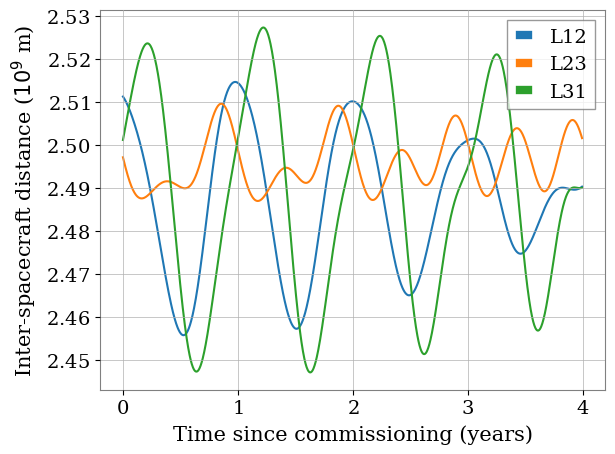

In [26]:
t = np.arange(0, orb_size*orb_dt, orb_dt)/(86400*365.25)

plt.figure(tight_layout=True)
plt.plot(t, L12)
plt.plot(t, L23)
plt.plot(t, L31)
plt.xlabel('Time since commissioning (years)')
plt.ylabel('Inter-spacecraft distance ($10^9$ m)')
plt.legend(['L12', 'L23', 'L31'])
plt.savefig(FIGURES / 'lisa_orbit.png', dpi=300, bbox_inches='tight')
plt.show()

## Figure 1

In [14]:
with h5py.File(orbits_path, 'r') as orb:
    orb_t0 = orb.attrs['t0']
    orb_size = orb.attrs['size']
    orb_dt = orb.attrs['dt']

pipe = {'t0': orb_t0 + orb_size*orb_dt/2, 'dt': 0.25,'size': int(15 * 3600 / 0.25),
        't_inj': 5 * 3600, 'keep_noises': ['test-mass', 'oms']}

glitches, gws = [], []
    
run_simulation(gws, glitches, pipe,
                None, None, orbits_path,
                simulation_path,
                disable_noise=pipe['keep_noises'])
tdi_dict = run_tdi(simulation_path, pipe)

X, Y, Z = tdi_dict['X'].value, tdi_dict['Y'].value, tdi_dict['Z'].value
A = (Z - X)/np.sqrt(2)
E = (X - 2*Y + Z)/np.sqrt(6)
T = (X + Y + Z)/np.sqrt(3)

Using default set of locking beatnote frequencies might cause interferometric beatnote frequencies to fall outside the requirement range of 5..25 MHz
You are using a measurement file in a version that might not be fully supported (got '2.1.0', official support up to '2.0')


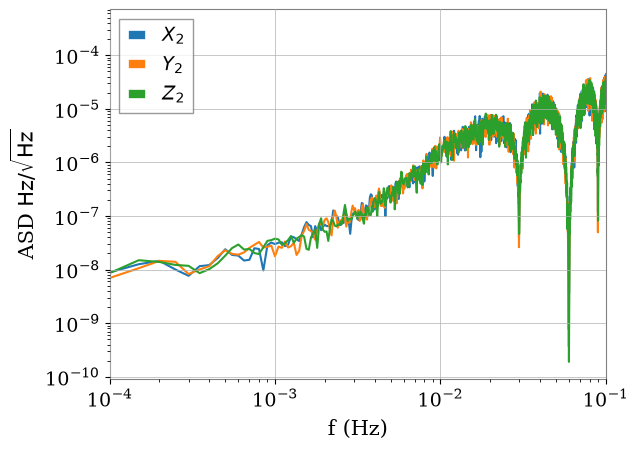

In [15]:
nperseg = 2e4/pipe['dt']
noverlap = None

SX_sim = estimate_psd(X, 1/pipe['dt'], nperseg=nperseg, noverlap=noverlap)
SY_sim = estimate_psd(Y, 1/pipe['dt'], nperseg=nperseg, noverlap=noverlap)
SZ_sim = estimate_psd(Z, 1/pipe['dt'], nperseg=nperseg, noverlap=noverlap)

SA_sim = estimate_psd(A, 1/pipe['dt'], nperseg=nperseg, noverlap=noverlap)
SE_sim = estimate_psd(E, 1/pipe['dt'], nperseg=nperseg, noverlap=noverlap)
ST_sim = estimate_psd(T, 1/pipe['dt'], nperseg=nperseg, noverlap=noverlap)

#fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True, constrained_layout=True)

plt.loglog(SX_sim[0], np.sqrt(SX_sim[1]), label='$X_2$')
plt.loglog(SY_sim[0], np.sqrt(SY_sim[1]), label='$Y_2$')
plt.loglog(SZ_sim[0], np.sqrt(SZ_sim[1]), label='$Z_2$')

plt.xlabel('f (Hz)')
plt.ylabel('ASD $\\text{Hz}/\sqrt{\\text{Hz}}$')
plt.xlim(1e-4, 1e-1)
plt.legend()

plt.savefig(FIGURES / 'noise_psd.png', dpi=300, bbox_inches='tight')
plt.show()

## Figure 2

In [67]:
def filter_by_snr(dataset_path, to_find=1, threshold=8):
    with h5py.File(dataset_path, 'r') as h5:
        t_qscan = h5['t_qscan'][:]
        f_qscan = h5['f_qscan'][:]
        qt = h5['QT'][:]
        tcen = h5['tcen'][:]

    idx = np.argmin(np.abs(tcen), axis=1)
    images = qt[np.arange(qt.shape[0]), idx]
    t_axes = t_qscan[np.arange(qt.shape[0]), idx]
    f_axes = f_qscan[np.arange(qt.shape[0]), idx]
    snrs = np.sqrt(images**2 - 1)

    good_idx = []
    for index in range(images.shape[0]):
        T_opt = []
        for j in range(snrs.shape[-1]):
            snr = snrs[index, :, :, j]
            t_axis = t_axes[index, :, j]
            f_axis = f_axes[index, :, j]
            _, T_grid = np.meshgrid(f_axis, t_axis, indexing="ij")

            T_opt.append(T_grid[snr > threshold])
        
        T_opt = np.concatenate(T_opt)/3600
        if len(T_opt) < 2:
            if to_find == 0:
                good_idx.append(index)
            continue
        try:
            times = np.linspace(np.min(t_axes[index])/3600, np.max(t_axes[index])/3600, 250)
            pdf = gaussian_kde(T_opt)(times)
            peaks, _ = find_peaks(pdf, width=1, prominence=0.05)

            if len(peaks) >= to_find:
                good_idx.append(index)
        except:
            pass

    return np.array(good_idx)

In [69]:
glitch_good_idx = filter_by_snr(glitch_testset_path, to_find=1, threshold=8)
gw_good_idx = filter_by_snr(gw_testset_path, to_find=1, threshold=8)

In [70]:
with h5py.File(glitch_testset_path, 'r') as h5:
    amp_arr = h5['amp'][:]
    beta_arr = h5['beta'][:]

with h5py.File(gw_testset_path, 'r') as h5:
    m1_arr = h5['m1'][:]
    m2_arr = h5['m2'][:]
    d_arr = h5['d'][:]

Mc_arr = chirp_mass(m1_arr, m2_arr)

In [71]:
good_amp = amp_arr[glitch_good_idx]
good_beta = beta_arr[glitch_good_idx]

glitch_all_idx = np.arange(0, len(amp_arr))
glitch_bad_idx = np.setdiff1d(glitch_all_idx, glitch_good_idx)
bad_amp = amp_arr[glitch_bad_idx]
bad_beta = beta_arr[glitch_bad_idx]

In [72]:
params = np.loadtxt(lpf_ord_param_path, skiprows=1)

lpf_betas = params[:, 0]
lpf_levels = params[:, 1]

bet_min = 1
amp_min, amp_max = 1e-14, 1e-11

lpf_levels = lpf_levels[lpf_betas > bet_min]
lpf_betas = lpf_betas[lpf_betas > bet_min]

lpf_betas = lpf_betas[(lpf_levels > amp_min) & (lpf_levels < amp_max)]
lpf_levels = lpf_levels[(lpf_levels > amp_min) & (lpf_levels < amp_max)]

In [73]:
good_Mc = Mc_arr[gw_good_idx]
good_d = d_arr[gw_good_idx]

gw_all_idx = np.arange(0, len(Mc_arr))
gw_bad_idx = np.setdiff1d(gw_all_idx, gw_good_idx)
bad_Mc = Mc_arr[gw_bad_idx]
bad_d = d_arr[gw_bad_idx]

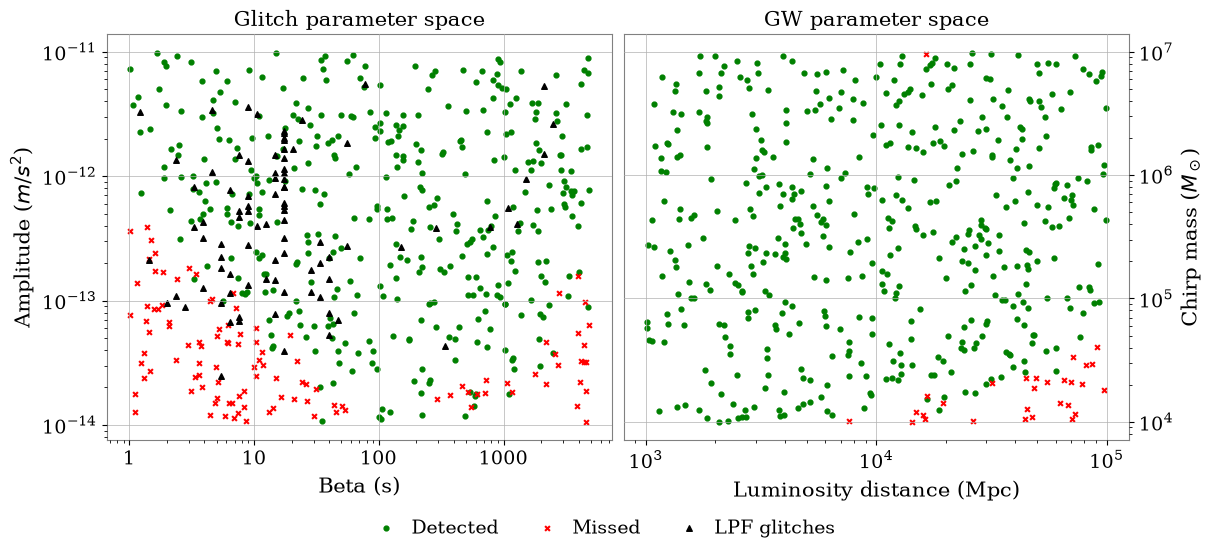

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

axes[0].scatter(good_beta, good_amp, color='green', s=12, marker='o', label='Detected')
axes[0].scatter(bad_beta, bad_amp, color='red', s=12, marker='x', label='Missed')
axes[0].scatter(lpf_betas, lpf_levels, color='black', s=16, marker='^', label='LPF glitches')

axes[0].set_xlabel('Beta (s)')
axes[0].set_ylabel('Amplitude ($m$/$s^2$)')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_title('Glitch parameter space')

axes[1].scatter(good_d, good_Mc, color='green', s=12, marker='o')
axes[1].scatter(bad_d, bad_Mc, color='red', s=12, marker='x')

axes[1].set_xlabel('Luminosity distance (Mpc)')
axes[1].set_ylabel('Chirp mass ($M_\odot$)')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('GW parameter space')
axes[1].yaxis.tick_right()
axes[1].yaxis.set_label_position("right")

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.1),
    ncol=3,
    frameon=False
)

plt.savefig(FIGURES / 'search_filtering.png', dpi=300, bbox_inches='tight')
plt.show()

## Figure 3

In [8]:
DEVICE = torch.device("mps")
def accuracy(model, loader, threshold=0.5):
    model.eval()
    
    soft_correct, hard_correct, soft_total, hard_total = 0, 0, 0, 0
    with torch.no_grad():
        for batch in loader:
            images, labels = batch[0].to(DEVICE), batch[1].to(DEVICE)
            
            outputs = model(images)
            predicted = (torch.sigmoid(outputs) > threshold).float()
            soft_correct += (predicted == labels).sum().item()
            hard_correct += ((predicted == labels).all(dim=1)).sum().item()
            soft_total += labels.numel()
            hard_total += labels.size(0)
    
    soft_acc = soft_correct/soft_total
    hard_acc = hard_correct/hard_total
    return soft_acc, hard_acc

In [17]:
lm_results_path = TRAINING_RESULTS/ 'run_010826_203219'
lm_results = torch.load(lm_results_path / 'results.pt')
lm_iters, lm_train_loss, lm_valid_loss, *_ = lm_results

model = CNN(width=6, bn=True, normalise=True)
device = torch.device("mps")
weights_path = lm_results_path / 'model_weights.pth'
model.load_state_dict(torch.load(weights_path, map_location=device))
model.to(device)
model.eval()

data = np.load(lm_results_path / 'roc_curves.npz')

fpr_gw_lm = data["fpr_gw"]
tpr_gw_lm = data["tpr_gw"]
auc_gw_lm = data["auc_gw"]

fpr_glitch_lm = data["fpr_glitch"]
tpr_glitch_lm = data["tpr_glitch"]
auc_glitch_lm = data["auc_glitch"]

lm_cm = np.load(lm_results_path / 'confusion_matrix.npz')['cm']

In [18]:
training_dataset_path2 = TRAINING_DATASETS / 'training_dataset.h5'
dataset = LISADataset(training_dataset_path)

unique_indices = np.unique(dataset.sim_indices)
all_indices = np.array(dataset.sim_indices)

rng = np.random.default_rng(42)
rng.shuffle(unique_indices)

n_total = len(unique_indices)
n_train = int(0.7 * n_total)
n_val   = int(0.2 * n_total)

train_sources = unique_indices[:n_train]
val_sources   = unique_indices[n_train:n_train+n_val]
test_sources  = unique_indices[n_train+n_val:]

train_indices = np.where(np.isin(all_indices, train_sources))[0]
val_indices   = np.where(np.isin(all_indices, val_sources))[0]
test_indices  = np.where(np.isin(all_indices, test_sources))[0]

train_dataset = Subset(dataset, train_indices)
val_dataset   = Subset(dataset, val_indices)
test_dataset  = Subset(dataset, test_indices)

In [19]:
train_loader = DataLoader(train_dataset, batch_size=64)
train_soft_acc, train_hard_acc = accuracy(model, train_loader)

val_loader = DataLoader(val_dataset, batch_size=64)
val_soft_acc, val_hard_acc = accuracy(model, val_loader)

test_loader = DataLoader(test_dataset, batch_size=64)
test_soft_acc, test_hard_acc = accuracy(model, test_loader)

print(f"Training Soft Accuracy: {train_soft_acc:.4f}, Training Hard Accuracy: {train_hard_acc:.4f}")
print(f"Validation Soft Accuracy: {val_soft_acc:.4f}, Validation Hard Accuracy: {val_hard_acc:.4f}")
print(f"Test Soft Accuracy: {test_soft_acc:.4f}, Test Hard Accuracy: {test_hard_acc:.4f}")

Training Soft Accuracy: 0.9988, Training Hard Accuracy: 0.9975
Validation Soft Accuracy: 0.9962, Validation Hard Accuracy: 0.9924
Test Soft Accuracy: 0.9960, Test Hard Accuracy: 0.9920


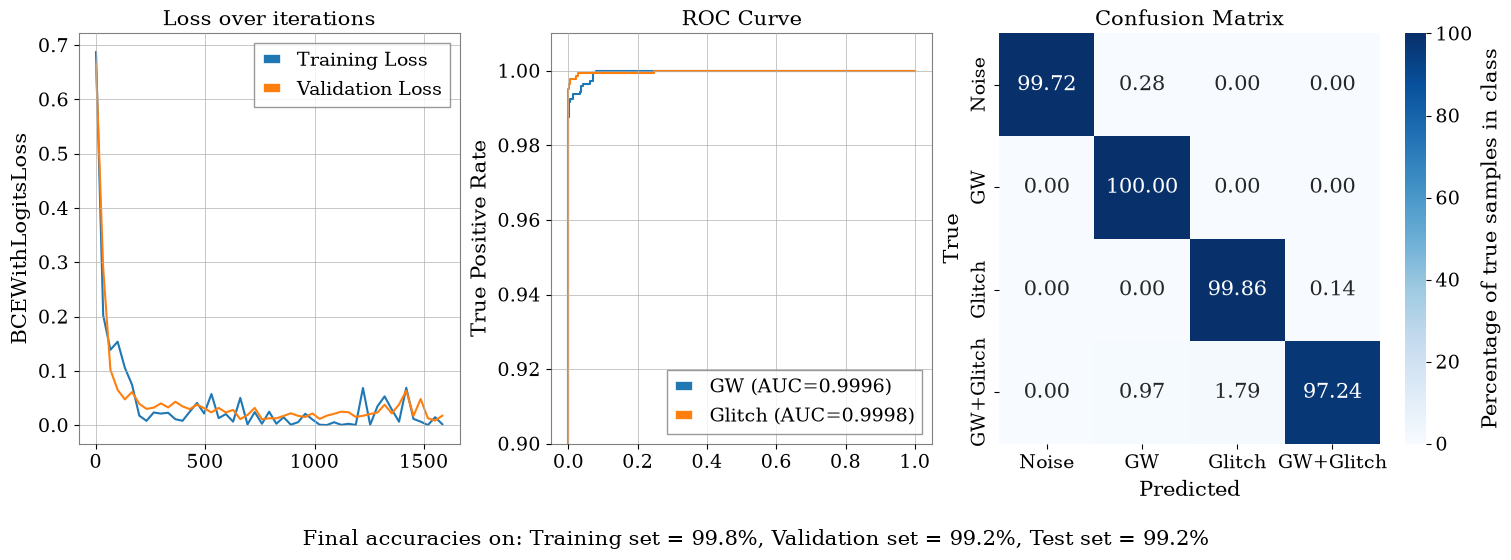

In [24]:
import matplotlib as mpl

fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 5),
    constrained_layout=True
)

labels_names = ["Noise", "GW", "Glitch", "GW+Glitch"]
label_size = mpl.rcParams["axes.labelsize"]

# ======================================================================
# LOW MASS
# ======================================================================

# Loss
axes[0].plot(
    lm_iters[:len(lm_train_loss)][:-1],
    lm_train_loss[:-1],
    label='Training Loss'
)
axes[0].plot(
    lm_iters[:len(lm_valid_loss)],
    lm_valid_loss,
    label='Validation Loss'
)

axes[0].set_ylabel("BCEWithLogitsLoss")
axes[0].set_title("Loss over iterations")
axes[0].legend()

# ROC
axes[1].plot(
    fpr_gw_lm,
    tpr_gw_lm,
    label=f"GW (AUC={auc_gw_lm:.4f})"
)

axes[1].plot(
    fpr_glitch_lm,
    tpr_glitch_lm,
    label=f"Glitch (AUC={auc_glitch_lm:.4f})"
)

#axes[1].set_xlim(0,1)
axes[1].set_ylim(0.9,1.01)
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()

# Confusion matrix
sns.heatmap(
    lm_cm,
    annot=True,
    cmap="Blues",
    ax=axes[2],
    fmt=".2f",
    xticklabels=labels_names,
    yticklabels=labels_names,
    vmin=0,
    vmax=100
)

axes[2].tick_params(axis='x', labelbottom=True)
axes[2].set_ylabel("True")
axes[2].set_xlabel("Predicted")
axes[2].set_title("Confusion Matrix")
axes[2].collections[0].colorbar.set_label(
    "Percentage of true samples in class"
)
axes[2].grid(False)

fig.text(
    0.5, -0.08,
    f"Final accuracies on: Training set = {train_hard_acc:.1%}, "
    f"Validation set = {val_hard_acc:.1%}, "
    f"Test set = {test_hard_acc:.1%}",
    ha="center",
    fontsize=15
)

plt.savefig(FIGURES / "model_performance.png", dpi=300, bbox_inches="tight")
plt.show()

## Figure 4

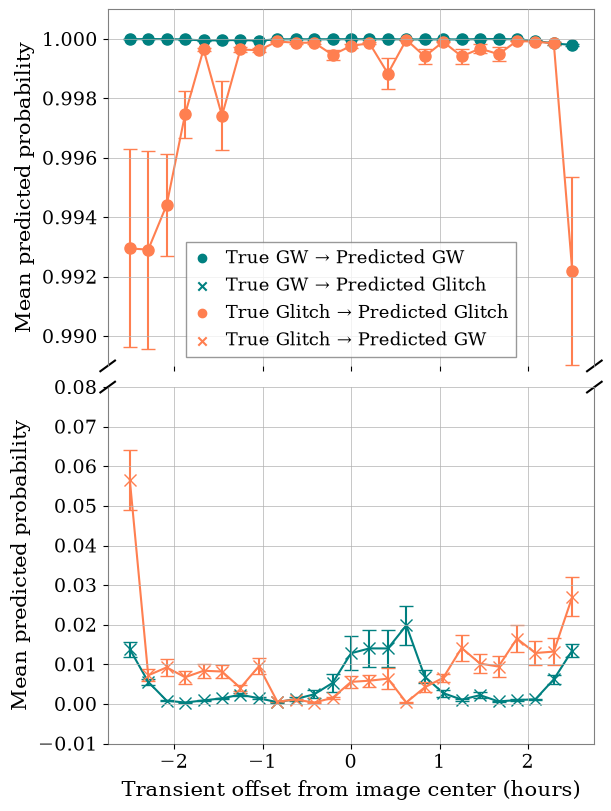

In [10]:
fig = plt.figure(figsize=(6, 8), constrained_layout=True)

gs = fig.add_gridspec(2, 1, height_ratios=[1, 1])

ax_top = fig.add_subplot(gs[0])
ax_bot = fig.add_subplot(gs[1], sharex=ax_top)

# ------------------------------------------------------------------
# Load results
# ------------------------------------------------------------------

save_dir = INFERENCE / "time_centering"
results = np.load(save_dir / "inference_results.npz")

times = results["times"] / 3600

gw_acc = results["gw_acc"]
glitch_acc = results["glitch_acc"]

gw_std = results["gw_std"]
glitch_std = results["glitch_std"]

# ------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------

s = 8

for ax in [ax_top, ax_bot]:

    ax.errorbar(
        times, gw_acc[:,0],
        yerr=gw_std[:,0]/len(gw_std[:,0]),
        marker='o', markersize=s,
        color='teal', capsize=5
    )

    ax.errorbar(
        times, gw_acc[:,1],
        yerr=gw_std[:,1]/len(gw_std[:,0]),
        marker='x', markersize=s,
        color='teal', capsize=5
    )

    ax.errorbar(
        times, glitch_acc[:,1],
        yerr=glitch_std[:,1]/len(glitch_std[:,0]),
        marker='o', markersize=s,
        color='coral', capsize=5
    )

    ax.errorbar(
        times, glitch_acc[:,0],
        yerr=glitch_std[:,0]/len(glitch_std[:,0]),
        marker='x', markersize=s,
        color='coral', capsize=5
    )

# ------------------------------------------------------------------
# Broken axis
# ------------------------------------------------------------------

ax_top.set_ylim(0.989, 1.001)
ax_bot.set_ylim(-0.01, 0.08)

ax_top.spines["bottom"].set_visible(False)
ax_bot.spines["top"].set_visible(False)

ax_top.tick_params(labelbottom=False)
ax_bot.xaxis.tick_bottom()

d = 0.015

kwargs = dict(transform=ax_top.transAxes,
              color='k',
              clip_on=False)

ax_top.plot((-d,+d),(-d,+d),**kwargs)
ax_top.plot((1-d,1+d),(-d,+d),**kwargs)

kwargs.update(transform=ax_bot.transAxes)

ax_bot.plot((-d,+d),(1-d,1+d),**kwargs)
ax_bot.plot((1-d,1+d),(1-d,1+d),**kwargs)

# ------------------------------------------------------------------
# Labels
# ------------------------------------------------------------------

ax_top.set_ylabel("Mean predicted probability")
ax_bot.set_ylabel("Mean predicted probability")
ax_bot.set_xlabel("Transient offset from image center (hours)")

# ------------------------------------------------------------------
# Legend
# ------------------------------------------------------------------

ax_top.scatter([], [], marker='o', color='teal',
               label='True GW → Predicted GW')

ax_top.scatter([], [], marker='x', color='teal',
               label='True GW → Predicted Glitch')

ax_top.scatter([], [], marker='o', color='coral',
               label='True Glitch → Predicted Glitch')

ax_top.scatter([], [], marker='x', color='coral',
               label='True Glitch → Predicted GW')

ax_top.legend(fontsize=13)

plt.savefig(FIGURES / "time_centering.png",
             dpi=300, bbox_inches="tight")

plt.show()